In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score)

# Task 1

In [2]:
df = pd.read_csv('heart_disease.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,70,1,3,130,322,0,2,109,0,2.4,1,3,1,1
1,67,0,2,115,564,0,2,160,0,1.6,1,0,3,0
2,57,1,1,124,261,0,0,141,0,0.3,0,0,3,1
3,64,1,3,128,263,0,0,105,1,0.2,1,1,3,0
4,74,0,1,120,269,0,2,121,1,0.2,0,1,1,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       270 non-null    int64  
 1   sex       270 non-null    int64  
 2   cp        270 non-null    int64  
 3   trestbps  270 non-null    int64  
 4   chol      270 non-null    int64  
 5   fbs       270 non-null    int64  
 6   restecg   270 non-null    int64  
 7   thalach   270 non-null    int64  
 8   exang     270 non-null    int64  
 9   oldpeak   270 non-null    float64
 10  slope     270 non-null    int64  
 11  ca        270 non-null    int64  
 12  thal      270 non-null    int64  
 13  target    270 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 29.7 KB


In [4]:
df['target'].nunique()

2

Binary classification problem

# Task 2

In [5]:
df['target'].value_counts()

target
0    150
1    120
Name: count, dtype: int64

In [6]:
lazy_acc = 150/(120+150)
print(f'Lazy Accuracy: {lazy_acc:.2f}')

Lazy Accuracy: 0.56


This is bad because you would miss anyone who does have heard disease and they would all die.

# Task 3

In [7]:
X = df[['age','trestbps','chol','thalach','sex']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Train shape: (216, 5)
Test shape: (54, 5)


# Task 4

In [8]:
model1 = LogisticRegression()
model1.fit(X_train, y_train)
y_preds = model1.predict(X_test)
acc1 = accuracy_score(y_test, y_preds)
print(f'First Model Accuracy: {acc1:.2f}')
print(f'Lazy Accuracy: {lazy_acc:.2f}')

First Model Accuracy: 0.80
Lazy Accuracy: 0.56


The model is more accurate and it does at least some work to actually predict people who do have heart disease. More measures (precision and/or recall) would be helpful to know how much better this model does.

# Task 5

In [9]:
model1.predict_proba(X_test)[:,1]

array([0.49804041, 0.5235616 , 0.22470988, 0.09888317, 0.30206214,
       0.56693849, 0.19664622, 0.39558201, 0.29566609, 0.38631635,
       0.31068382, 0.52976145, 0.44364161, 0.90383247, 0.54441857,
       0.27412218, 0.71326298, 0.31499776, 0.58364492, 0.26566961,
       0.77529285, 0.27615459, 0.5459581 , 0.24034254, 0.49565074,
       0.49676533, 0.23907006, 0.50665821, 0.14286242, 0.20439498,
       0.16429941, 0.16609628, 0.48904618, 0.05436917, 0.4487567 ,
       0.62214203, 0.48785304, 0.31183015, 0.89769869, 0.62312026,
       0.32283474, 0.19728962, 0.39559536, 0.24691701, 0.02675455,
       0.12452564, 0.42063601, 0.76435858, 0.74499616, 0.12708968,
       0.23444053, 0.08917317, 0.17484729, 0.72985929])

In [10]:
print(model1.predict(X_test)
)
print(model1.predict_proba(X_test)[:,1])

[0 1 0 0 0 1 0 0 0 0 0 1 0 1 1 0 1 0 1 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0
 0 1 1 0 0 0 0 0 0 0 1 1 0 0 0 0 1]
[0.49804041 0.5235616  0.22470988 0.09888317 0.30206214 0.56693849
 0.19664622 0.39558201 0.29566609 0.38631635 0.31068382 0.52976145
 0.44364161 0.90383247 0.54441857 0.27412218 0.71326298 0.31499776
 0.58364492 0.26566961 0.77529285 0.27615459 0.5459581  0.24034254
 0.49565074 0.49676533 0.23907006 0.50665821 0.14286242 0.20439498
 0.16429941 0.16609628 0.48904618 0.05436917 0.4487567  0.62214203
 0.48785304 0.31183015 0.89769869 0.62312026 0.32283474 0.19728962
 0.39559536 0.24691701 0.02675455 0.12452564 0.42063601 0.76435858
 0.74499616 0.12708968 0.23444053 0.08917317 0.17484729 0.72985929]


The model was very unsure about the first test patient. It was very sure about the fourth.

### Task 6:

- A DecisionTree that goes too deep has no choice but to overfit itself, as happened with this first DT.

In [17]:
from sklearn.tree import DecisionTreeClassifier
dt_no_max = DecisionTreeClassifier(random_state=42)
dt_no_max.fit(X_train, y_train)
dt_no_max_pred = dt_no_max.predict(X_test)
dt_no_max_pred_train = dt_no_max.predict(X_train)
dt_no_max_acc = accuracy_score(y_test, dt_no_max_pred)
dt_no_max_acc_train = accuracy_score(y_train, dt_no_max_pred_train)
print(f"No-Max Prediction (Train): {dt_no_max_acc_train:.2f}")
print(f"No-Max Prediction (Test): {dt_no_max_acc:.2f}")

dt_shallow = DecisionTreeClassifier(max_depth= 3, random_state=42)
dt_shallow.fit(X_train, y_train)
dt_shallow_pred = dt_shallow.predict(X_test)
dt_shallow_pred_train = dt_shallow.predict(X_train)
dt_shallow_acc = accuracy_score(y_test, dt_shallow_pred)
dt_shallow_acc_train = accuracy_score(y_train, dt_shallow_pred_train)
print(f"Shallow Prediction (Train): {dt_shallow_acc_train:.2f}")
print(f"Shallow Prediction (Test): {dt_shallow_acc:.2f}")



No-Max Prediction (Train): 1.00
No-Max Prediction (Test): 0.56
Shallow Prediction (Train): 0.77
Shallow Prediction (Test): 0.67


### Task 7:

- We had 8 false negatives, this is the most dangerous metric for this clinic, as it is the only one likely to get someone killed if inaccurate.

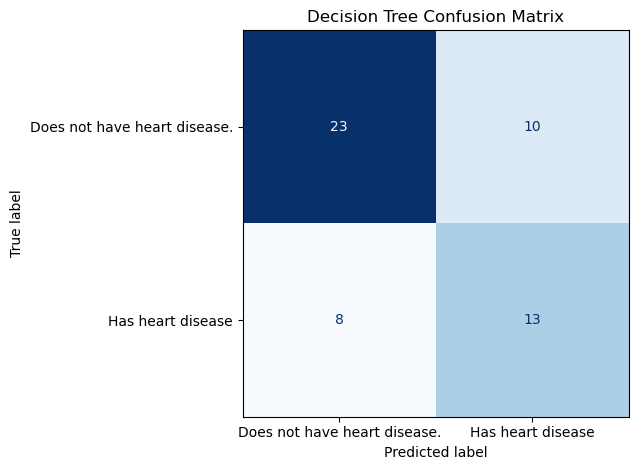

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,                                        
    dt_shallow_pred,                                 
    display_labels=["Does not have heart disease.", "Has heart disease"],               
    cmap="Blues",                               
    colorbar=False                              
)

plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()

### Task 8

- Recall, as you need to minimize the amount of false negatives.

In [30]:
prec = precision_score(y_test, dt_shallow_pred)
rec  = recall_score(y_test, dt_shallow_pred)

print(f'Precision: {prec:.2f}')
print(f'Recall: {rec:.2f}')

Precision: 0.57
Recall: 0.62


### Advanced, Task 9:

- Recall increased dramatically, as there were no false negatives, this occured at the expense of turning some true negatives into false positives.

[1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1]
Precision: 0.66
Recall: 1.00


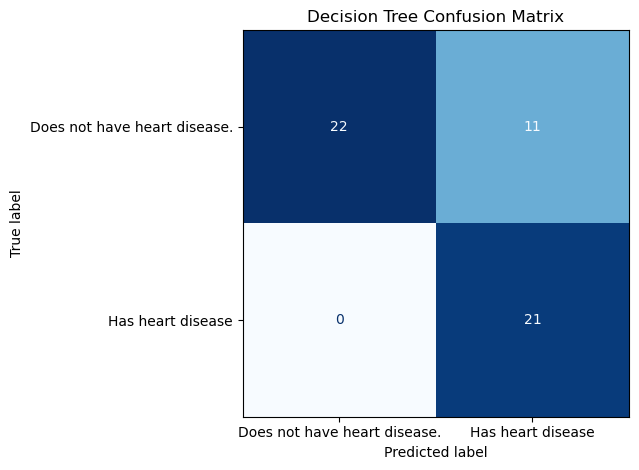

In [28]:
lower_threshold = .3
probas = model1.predict_proba(X_test)
new_predictions = []
for i in probas:
    if i[1] <= .3:
        new_predictions.append(0)
    else:
        new_predictions.append(1)
print(new_predictions)

prec = precision_score(y_test, new_predictions)
rec  = recall_score(y_test, new_predictions)

print(f'Precision: {prec:.2f}')
print(f'Recall: {rec:.2f}')

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,                                        
    new_predictions,                                 
    display_labels=["Does not have heart disease.", "Has heart disease"],               
    cmap="Blues",                               
    colorbar=False                              
)

plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()

### Advanced, Task 10:

- We would choose to hand the clinic the lower threshold DecisionTree. While we would need to test further and cross validate, it thus far is the only model we have which does not have any false negatives, while not creating an exorbitant amount of false positives. False Negatives may very likely lead to the death of a patient, so in our opinion, the value in choosing a model which is unlikely to predict false negatives, is of the utmost important.

- However, we would probably give our soulless corporate overlords multiple models and let them decide what K/D rate they want.

In [33]:
from sklearn.metrics import f1_score
print(f'First Model Accuracy: {acc1:.2f}')
print(f'First Model Precision: {precision_score(y_test, y_preds):.2f}')
print(f'First Model Recall: {recall_score(y_test, y_preds):.2f}')
print(f'First Model F1: {f1_score(y_test, y_preds):.2f}')

prec = precision_score(y_test, new_predictions)
rec  = recall_score(y_test, new_predictions)
acc = accuracy_score(y_test, new_predictions)
print(f"Lower Threshold DT Accuracy: {acc:.2f}")
print(f'Lower Threshold DT Precision: {prec:.2f}')
print(f'Lower Threshold DT Recall: {rec:.2f}')
print(f'Lower Threshold DT F1: {f1_score(y_test, new_predictions):.2f}')

First Model Accuracy: 0.80
First Model Precision: 0.81
First Model Recall: 0.62
First Model F1: 0.70
Lower Threshold DT Accuracy: 0.80
Lower Threshold DT Precision: 0.66
Lower Threshold DT Recall: 1.00
Lower Threshold DT F1: 0.79
